<a href="https://colab.research.google.com/github/Yovana-Palencia/Mineria-De-Datos/blob/main/Tarea_Digitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Claves del dataset: dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Forma de los datos: (1797, 64)
Forma de las imágenes: (1797, 8, 8)
Etiquetas únicas: [0 1 2 3 4 5 6 7 8 9]


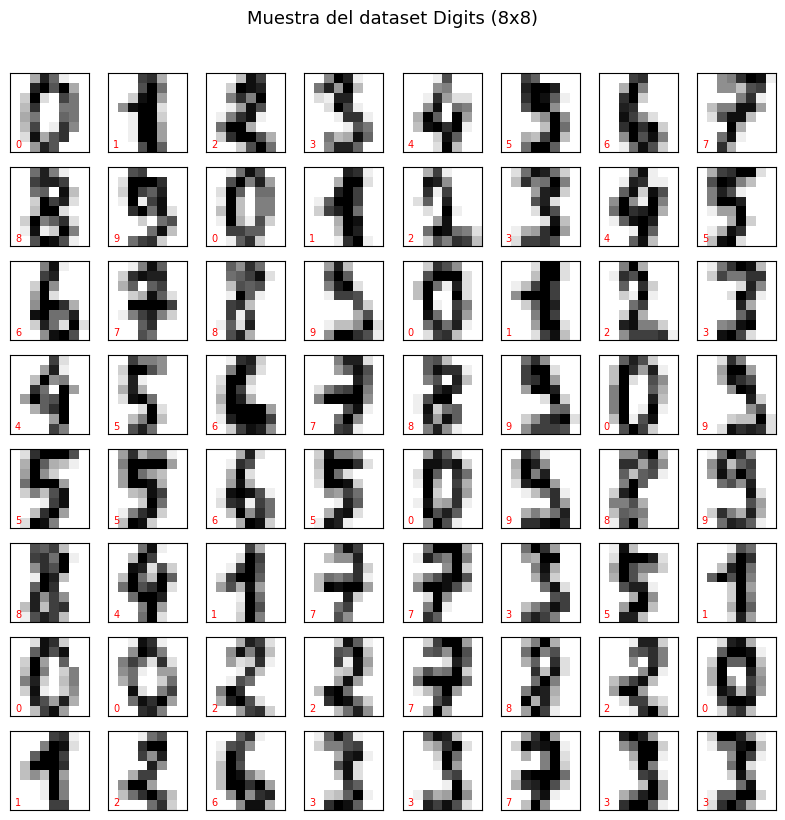


Muestras de entrenamiento: 1437
Muestras de prueba:        360

Modelo                 Accuracy
KNN (k=5)                0.9639
SVM (RBF)                0.9806
Random Forest            0.9611

Mejor modelo: SVM (RBF) (accuracy = 0.9806)

--- Reporte de clasificación: KNN (k=5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg 

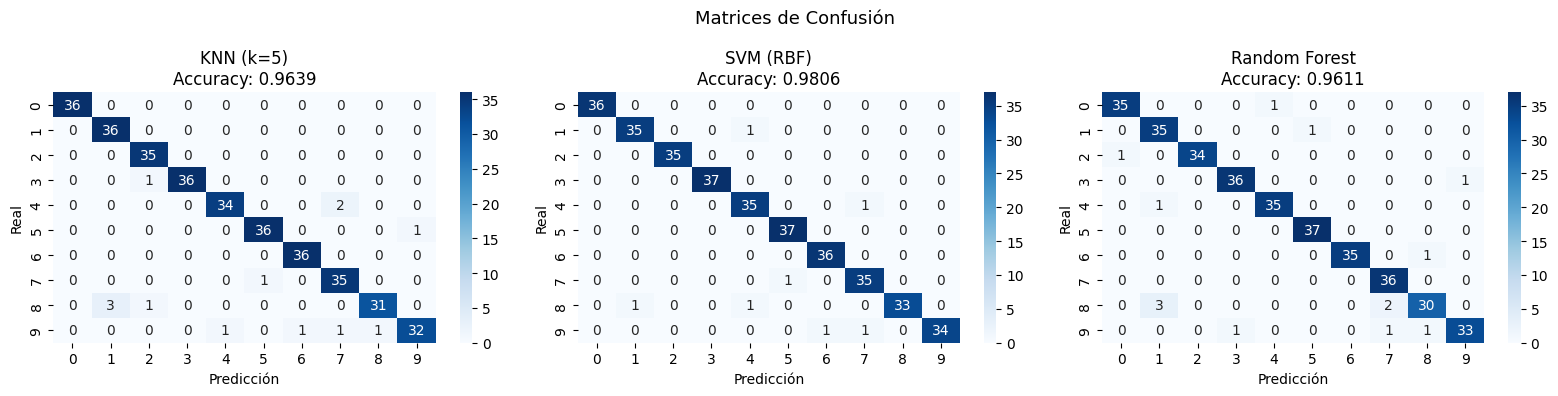

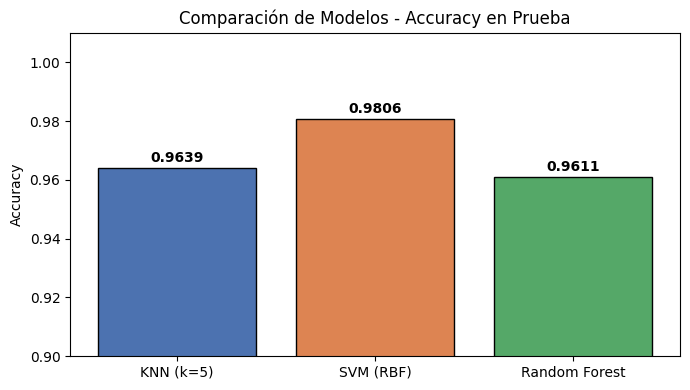

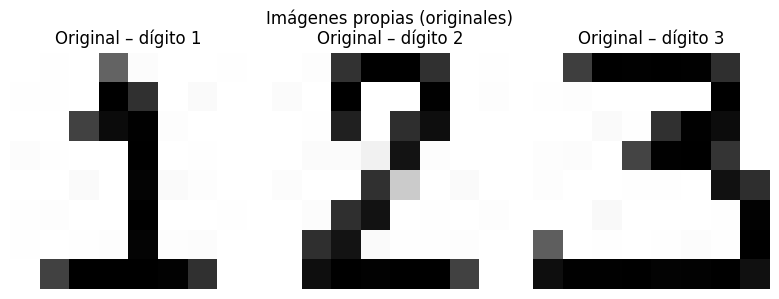

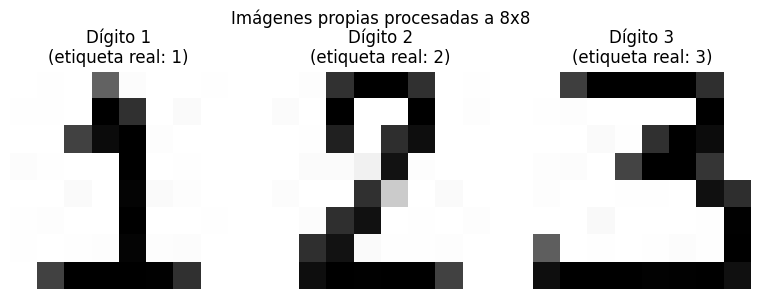


Imagen         Real        KNN        SVM         RF
Dígito 1          1          2          4          1
Dígito 2          2          2          4          2
Dígito 3          3          6          4          9


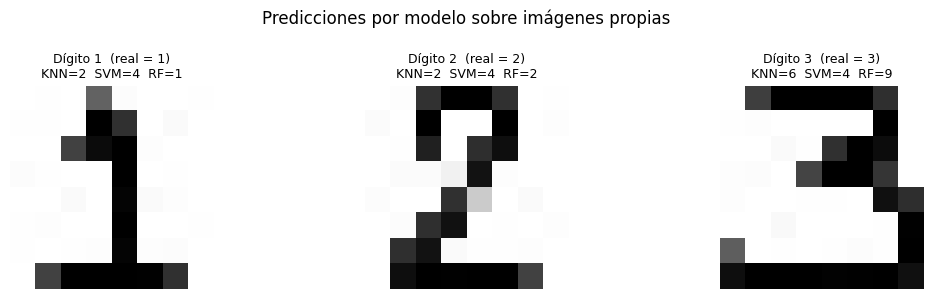


RESUMEN FINAL
Accuracy en conjunto de prueba:
  KNN (k=5)           : 0.9639
  SVM (RBF)           : 0.9806  Mejor modelo
  Random Forest       : 0.9611

Predicciones sobre imágenes:
  Imagen        Real    KNN    SVM     RF
  Dígito 1         1      2      4      1
  Dígito 2         2      2      4      2
  Dígito 3         3      6      4      9


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


#Carga y exploración del DATASET
digits = load_digits()

print("Claves del dataset:", digits.keys())
print("Forma de los datos:", digits.data.shape)        # (1797, 64)
print("Forma de las imágenes:", digits.images.shape)   # (1797, 8, 8)
print("Etiquetas únicas:", np.unique(digits.target))

#Visualizar 64 imágenes de muestra
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    ax.text(0, 7, str(digits.target[i]), color='red', fontsize=7)
plt.suptitle("Muestra del dataset Digits (8x8)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target,
    test_size=0.20,
    random_state=42,
    stratify=digits.target
)
print(f"\nMuestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba:        {X_test.shape[0]}")

# Escalar características (necesario para KNN y SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

#Entrenamiento de los 3 modelos
#K-Nearest Neighbors (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

#SVM (kernel RBF)
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)

#Random Forest (100 estimadores)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)   # RF no requiere escalado

#Evaluación en conjunto de prueba
modelos = {
    'KNN (k=5)':     (knn, X_test_sc),
    'SVM (RBF)':     (svm, X_test_sc),
    'Random Forest': (rf,  X_test),
}

print("\n" + "="*45)
print(f"{'Modelo':<20} {'Accuracy':>10}")
print("="*45)
resultados = {}
for nombre, (modelo, X) in modelos.items():
    y_pred = modelo.predict(X)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = (acc, y_pred)
    print(f"{nombre:<20} {acc:>10.4f}")
print("="*45)

mejor = max(resultados, key=lambda k: resultados[k][0])
print(f"\nMejor modelo: {mejor} (accuracy = {resultados[mejor][0]:.4f})")

# Reporte detallado por clase
for nombre in resultados:
    print(f"\n--- Reporte de clasificación: {nombre} ---")
    print(classification_report(y_test, resultados[nombre][1]))

#Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nombre, (acc, y_pred)) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(f"{nombre}\nAccuracy: {acc:.4f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.suptitle("Matrices de Confusión", fontsize=13)
plt.tight_layout()
plt.show()

#Gráfica comparativa de accuracy
nombres_m = list(resultados.keys())
accuracies = [resultados[n][0] for n in nombres_m]
colores = ['#4C72B0', '#DD8452', '#55A868']
plt.figure(figsize=(7, 4))
bars = plt.bar(nombres_m, accuracies, color=colores, edgecolor='black')
plt.ylim(0.9, 1.01)
plt.ylabel("Accuracy")
plt.title("Comparación de Modelos - Accuracy en Prueba")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{acc:.4f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

#Carga y procesamiento de los digitos
def procesar_imagen(ruta):
    """
    Carga imagen, convierte a escala de grises, redimensiona a 8x8
    y normaliza al rango [0, 16] igual que el dataset Digits de sklearn.
    El fondo claro queda en 0 y la tinta oscura queda en 16.
    """
    img = Image.open(ruta).convert('L')          # escala de grises
    img = img.resize((8, 8), Image.LANCZOS)      # redimensionar a 8x8
    arr = np.array(img, dtype=float)
    arr = 255 - arr                              # invertir: tinta=255, fondo=0
    arr = arr / 255.0 * 16                       # escalar a [0, 16]
    arr = np.clip(arr, 0, 16)
    return arr

imagenes_propias = {
    'Dígito 1': (procesar_imagen('/content/1.jpg'), 1),
    'Dígito 2': (procesar_imagen('/content/2.jpg'), 2),
    'Dígito 3': (procesar_imagen('/content/3.jpg'), 3),
}

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, (ruta, real) in zip(axes, [('/content/1.jpg', 1),
                                    ('/content/2.jpg', 2),
                                    ('/content/3.jpg', 3)]):
    img_orig = Image.open(ruta).convert('L')
    ax.imshow(img_orig, cmap='gray')
    ax.set_title(f"Original – dígito {real}")
    ax.axis('off')
plt.suptitle("Imágenes propias (originales)", fontsize=12)
plt.tight_layout()
plt.show()

#Mostrar imágenes procesadas a 8x8
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, (nombre, (img, real)) in zip(axes, imagenes_propias.items()):
    ax.imshow(img, cmap='binary', interpolation='nearest', vmin=0, vmax=16)
    ax.set_title(f"{nombre}\n(etiqueta real: {real})")
    ax.axis('off')
plt.suptitle("Imágenes propias procesadas a 8x8", fontsize=12)
plt.tight_layout()
plt.show()


#Predicción
print("\n" + "="*60)
print(f"{'Imagen':<12} {'Real':>6} {'KNN':>10} {'SVM':>10} {'RF':>10}")
print("="*60)

predicciones = {}
for nombre, (img, etiqueta_real) in imagenes_propias.items():
    vector    = img.flatten().reshape(1, -1)   # shape (1, 64)
    vector_sc = scaler.transform(vector)       # escalado para KNN y SVM

    pred_knn = knn.predict(vector_sc)[0]
    pred_svm = svm.predict(vector_sc)[0]
    pred_rf  = rf.predict(vector)[0]

    predicciones[nombre] = {
        'real': etiqueta_real,
        'KNN': pred_knn,
        'SVM': pred_svm,
        'RF':  pred_rf,
    }
    print(f"{nombre:<12} {etiqueta_real:>6} {pred_knn:>10} {pred_svm:>10} {pred_rf:>10}")

print("="*60)

#Visualización final con imágenes y predicciones
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (nombre, (img, real)) in zip(axes, imagenes_propias.items()):
    p = predicciones[nombre]
    ax.imshow(img, cmap='binary', interpolation='nearest', vmin=0, vmax=16)
    ax.set_title(
        f"{nombre}  (real = {real})\n"
        f"KNN={p['KNN']}  SVM={p['SVM']}  RF={p['RF']}",
        fontsize=9
    )
    ax.axis('off')
plt.suptitle("Predicciones por modelo sobre imágenes propias", fontsize=12)
plt.tight_layout()
plt.show()

print("\nRESUMEN FINAL")
print("="*50)
print("Accuracy en conjunto de prueba:")
for nombre, (acc, _) in resultados.items():
    marca = "  Mejor modelo" if nombre == mejor else ""
    print(f"  {nombre:<20}: {acc:.4f}{marca}")

print("\nPredicciones sobre imágenes:")
print(f"  {'Imagen':<12} {'Real':>5} {'KNN':>6} {'SVM':>6} {'RF':>6}")
for nombre, p in predicciones.items():
    print(f"  {nombre:<12} {p['real']:>5} {p['KNN']:>6} {p['SVM']:>6} {p['RF']:>6}")
print("="*50)